# NSW Active-Fire Data Science Exploration

**Private, exploratory notebook** -- not the public reproducibility artifact (`notebooks/active-fire-kaggle/`). This widens the case-study window beyond the original 14-day reliability pilot to look at real hotspot, weather, and land-cover data together, and prototype the auxiliary-data features the eventual multimodal forecasting model (D-011/D-012, Option B) will need.

**Region:** Greater Blue Mountains bbox (same as the reliability pilot). **Window:** 15 Dec 2019 -- 15 Jan 2020, chosen after checking live record counts across several candidate windows -- this one spans the Black Summer activity surge in December into the original pilot's quieter January window (133,286 DEA hotspot records vs. the pilot's 19,849 for 14 days), giving real temporal variation to explore rather than a flat peak. **Not yet the confirmed case-study region/horizon** -- those are still open questions for Friday's meeting (see `assignments/week-02-mentor-meeting-prep-2026-08-07.md`); this is prototyping the *process*, reusable once the real scope is frozen.

## 1. Setup

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from analysis import (
    load_hotspots, load_weather, load_landcover, daily_hotspot_counts,
    sensor_composition, confidence_summary, rolling_dryness_features,
    merge_hotspots_weather, landcover_class_distribution,
)

DATA_DIR = Path('data')
config = json.loads(Path('config.json').read_text())
config

{'region_name': 'Greater Blue Mountains (widened from the reliability-pilot bbox)',
 'bbox_wgs84': [149.5, -33.7, 151.0, -32.3],
 'start_utc': '2019-12-15T00:00:00Z',
 'end_utc_exclusive': '2020-01-15T00:00:00Z',
 'dea_layer': 'public:hotspots',
 'silo_grid_points': [{'name': 'centroid', 'lat': -33.0, 'lon': 150.25},
  {'name': 'north', 'lat': -32.45, 'lon': 150.25},
  {'name': 'south', 'lat': -33.55, 'lon': 150.25}],
 'landcover_layer': 'ga_ls_landcover',
 'landcover_year': '2020-01-01',
 'notes': "Exploratory/private notebook, not the public reproducibility pipeline. Window chosen to span the Dec 2019 activity surge into the original reliability-pilot's quieter Jan 2020 window (133k DEA hotspot records vs. the pilot's 19.8k for 14 days) -- checked live record counts before committing to this range."}

## 2. Hotspot EDA (MODIS/VIIRS/AHI, DEA Hotspots WFS)

Widened window vs. the original reliability pilot's 14-day snapshot -- enough range to look at day-to-day variation, not just a single-event footprint.

In [2]:
hotspots = load_hotspots(DATA_DIR / 'dea_hotspots_wide.geojson')
print(f'{len(hotspots):,} hotspot records, {hotspots["date"].nunique()} distinct days')
hotspots.head()

133,286 hotspot records, 31 distinct days


,id,satellite,satellite_nssdc_id,satellite_operating_agency,sensor,orbit,start_dt,stop_dt,filename,process_dt,...,geometry,temp_kelvin,power,confidence,datetime,australian_state,accuracy,lon,lat,date
0,31744283,SUOMI NPP,2011-061A,NASA/NOAA,VIIRS,42459.0,2020-01-07T03:03:07Z,2020-01-07T03:11:37Z,Npp20200107T030307Z20200107T031137Zhotspots.txt,None,...,"{'type': 'Point', 'coordinates': [150.9424, -3...",313.22,15.6,56,2020-01-07 03:04:31+00:00,NSW,± 0.375km,150.9424,-32.6579,2020-01-07
1,31744525,HIMAWARI-8,2014-060A,JMA,AHI,NaN,2020-01-07T03:30:00Z,2020-01-07T03:30:00Z,IDE00100.202001070330.txt,None,...,"{'type': 'Point', 'coordinates': [150.3066, -3...",803.80,32.0,50,2020-01-07 03:30:00+00:00,NSW,± 2km,150.3066,-32.4396,2020-01-07
2,31744716,HIMAWARI-8,2014-060A,JMA,AHI,NaN,2020-01-07T03:40:00Z,2020-01-07T03:40:00Z,IDE00100.202001070340.txt,None,...,"{'type': 'Point', 'coordinates': [150.3066, -3...",427.60,46.3,50,2020-01-07 03:40:00+00:00,NSW,± 2km,150.3066,-32.4396,2020-01-07
3,31744928,HIMAWARI-8,2014-060A,JMA,AHI,NaN,2020-01-07T03:50:00Z,2020-01-07T03:50:00Z,IDE00100.202001070350.txt,None,...,"{'type': 'Point', 'coordinates': [149.619, -32...",608.30,53.1,50,2020-01-07 03:50:00+00:00,NSW,± 2km,149.6190,-32.6631,2020-01-07
4,31745332,HIMAWARI-8,2014-060A,JMA,AHI,NaN,2020-01-07T04:10:00Z,2020-01-07T04:10:00Z,IDE00100.202001070410.txt,None,...,"{'type': 'Point', 'coordinates': [150.6484, -3...",423.80,54.2,50,2020-01-07 04:10:00+00:00,NSW,± 2km,150.6484,-32.4933,2020-01-07


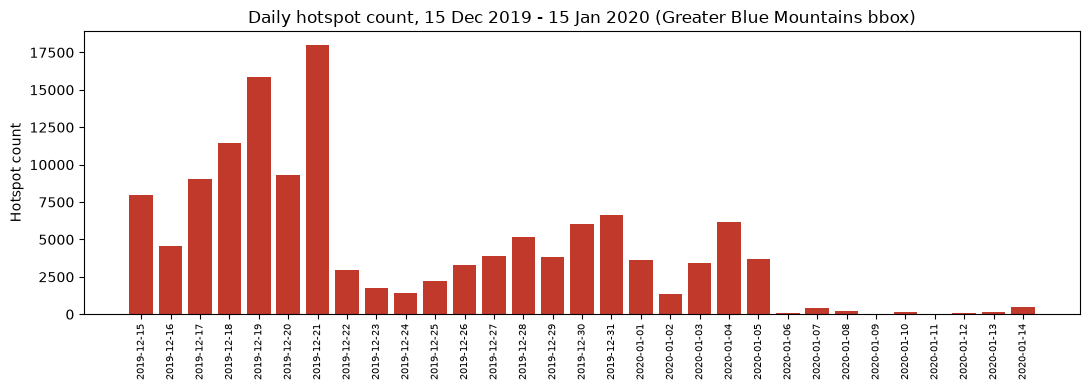

In [3]:
daily_counts = daily_hotspot_counts(hotspots)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(daily_counts['date'].astype(str), daily_counts['hotspot_count'], color='#c0392b')
ax.set_title('Daily hotspot count, 15 Dec 2019 - 15 Jan 2020 (Greater Blue Mountains bbox)')
ax.set_ylabel('Hotspot count')
ax.tick_params(axis='x', rotation=90, labelsize=7)
fig.tight_layout()
plt.show()

### Sensor composition and per-sensor confidence

Confidence is reported on different scales per sensor (numeric for some, coarse nominal/high for others -- this project found that the hard way before, see T-025). Reporting per-sensor stats rather than one pooled number.

In [4]:
composition = sensor_composition(hotspots)
print('Sensor composition:', composition)
confidence_summary(hotspots)

Sensor composition: {'VIIRS': 40176, 'AHI': 81091, 'MODIS': 10798, 'AVHRR': 1221}


,count,mean,median,min,max,nunique
sensor,,,,,,
AHI,81091,50.000000,50.0,50,50,1
AVHRR,1221,50.000000,50.0,50,50,1
MODIS,10798,64.561308,50.0,0,100,100
VIIRS,40176,20.735663,8.0,0,100,100


## 3. Weather EDA (SILO, gridded daily climate)

Three points spanning the bbox (north/centroid/south) -- checking whether weather is roughly uniform across the region or varies enough to matter for a spatial model. **SILO does not provide wind speed/direction** (checked against SILO's own variable list) -- flagged rather than silently omitted; wind will need BOM station data or ERA5 later.

In [5]:
weather = load_weather(DATA_DIR, [p['name'] for p in config['silo_grid_points']])
weather['centroid'][['date', 'daily_rain', 'max_temp', 'min_temp', 'vp_deficit', 'rh_tmax']].head()

,date,daily_rain,max_temp,min_temp,vp_deficit,rh_tmax
0,2019-12-15,0.0,34.3,14.7,24.2,31.1
1,2019-12-16,0.0,30.7,16.9,25.9,23.3
2,2019-12-17,0.0,29.5,13.0,19.3,31.8
3,2019-12-18,0.0,34.6,11.6,26.8,23.5
4,2019-12-19,0.0,39.7,15.1,41.1,14.9


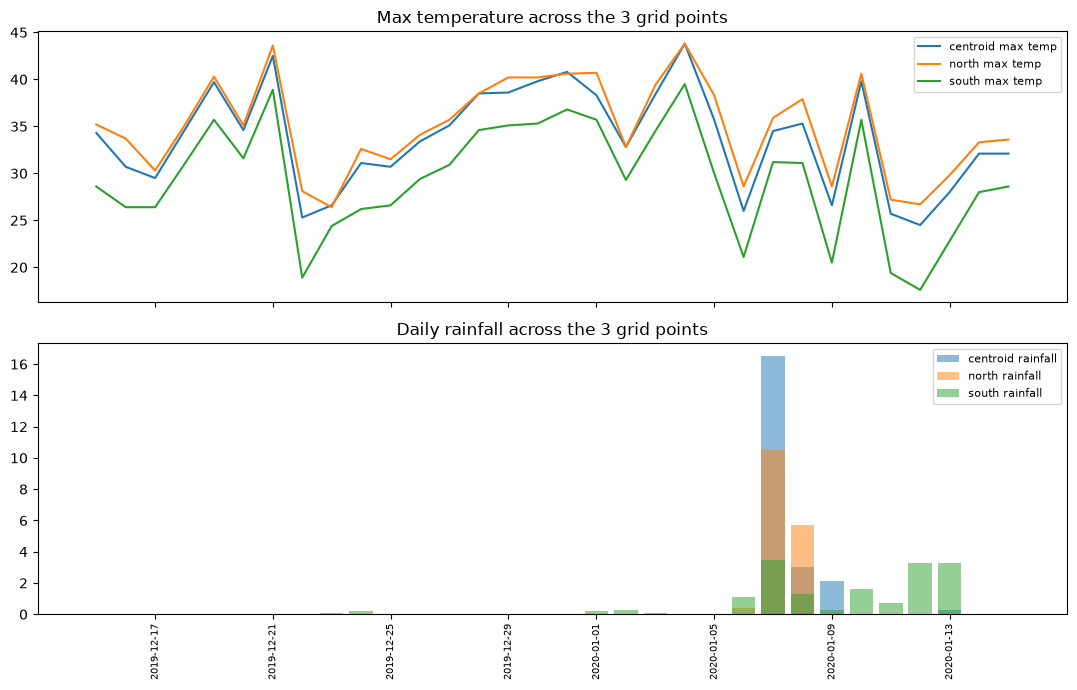

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for name, df in weather.items():
    axes[0].plot(df['date'], df['max_temp'], label=f'{name} max temp')
    axes[1].bar(df['date'], df['daily_rain'], alpha=0.5, label=f'{name} rainfall')
axes[0].set_title('Max temperature across the 3 grid points')
axes[0].legend(fontsize=8)
axes[1].set_title('Daily rainfall across the 3 grid points')
axes[1].legend(fontsize=8)
plt.xticks(rotation=90, fontsize=7)
fig.tight_layout()
plt.show()

## 4. Does dryness track hotspot activity?

Rough sanity check, not a rigorous causal claim -- rolling rainfall/temperature features (candidates for the forecasting model) against the daily hotspot count.

In [7]:
weather_features = rolling_dryness_features(weather['centroid'])
merged = merge_hotspots_weather(daily_counts, weather_features)
merged[['date', 'hotspot_count', 'rain_7d_sum', 'consecutive_dry_days', 'max_temp_7d_mean', 'vpd_7d_mean']]

,date,hotspot_count,rain_7d_sum,consecutive_dry_days,max_temp_7d_mean,vpd_7d_mean
0,2019-12-15,7977.0,0.0,1,34.300000,24.200000
1,2019-12-16,4588.0,0.0,2,32.500000,25.050000
2,2019-12-17,9070.0,0.0,3,31.500000,23.133333
3,2019-12-18,11445.0,0.0,4,32.275000,24.050000
4,2019-12-19,15872.0,0.0,5,33.760000,27.460000
5,2019-12-20,9297.0,0.0,6,33.900000,28.016667
6,2019-12-21,18009.0,0.0,7,35.128571,29.885714
7,2019-12-22,2969.0,0.0,8,33.842857,28.685714
8,2019-12-23,1744.0,0.0,9,33.257143,27.128571
9,2019-12-24,1447.0,0.0,10,33.485714,26.900000


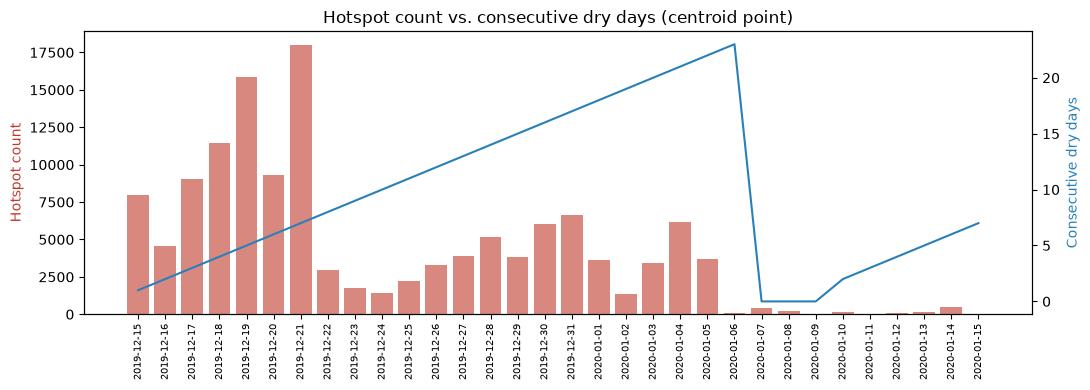

Correlation with daily hotspot count:
hotspot_count           1.000000
rain_7d_sum            -0.498040
consecutive_dry_days   -0.027539
max_temp_7d_mean        0.105907
vpd_7d_mean             0.120515
Name: hotspot_count, dtype: float64


In [8]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(merged['date'].astype(str), merged['hotspot_count'], color='#c0392b', alpha=0.6, label='Hotspot count')
ax1.set_ylabel('Hotspot count', color='#c0392b')
ax2 = ax1.twinx()
ax2.plot(merged['date'].astype(str), merged['consecutive_dry_days'], color='#2980b9', label='Consecutive dry days')
ax2.set_ylabel('Consecutive dry days', color='#2980b9')
plt.title('Hotspot count vs. consecutive dry days (centroid point)')
ax1.tick_params(axis='x', rotation=90, labelsize=7)
fig.tight_layout()
plt.show()

correlation = merged[['hotspot_count', 'rain_7d_sum', 'consecutive_dry_days', 'max_temp_7d_mean', 'vpd_7d_mean']].corr()['hotspot_count']
print('Correlation with daily hotspot count:')
print(correlation)

## 5. Land cover at hotspot locations (DEA Land Cover, Landsat)

Sampled a subset of unique hotspot locations (not all ~130k -- see `fetch_landcover.py` for why: one WMS call per unique location, and hotspots cluster heavily in space, so a few hundred samples already covers most of the distinct land-cover classes present).

In [9]:
landcover = load_landcover(DATA_DIR / 'landcover_sample.json')
print(f'{len(landcover)} locations resolved')
distribution = landcover_class_distribution(landcover)
distribution

500 locations resolved


level3_label
Natural Terrestrial Vegetation       491
Cultivated Terrestrial Vegetation      6
No data                                2
Natural Bare Surface                   1
Name: count, dtype: int64

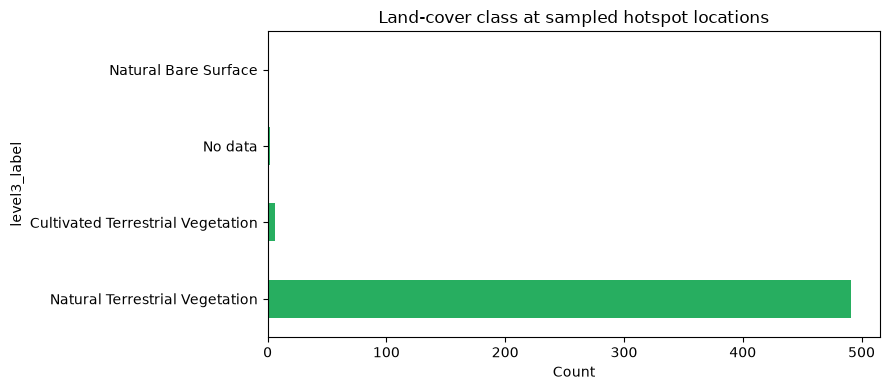

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
distribution.plot(kind='barh', ax=ax, color='#27ae60')
ax.set_title('Land-cover class at sampled hotspot locations')
ax.set_xlabel('Count')
fig.tight_layout()
plt.show()

## 6. Candidate features for the forecasting model

Not a final feature set -- a working list from this exploration, to refine once the case-study region/horizon are frozen (Friday's meeting).

**Hotspot-history branch:**
- Rolling hotspot density (count in past N days, within a spatial radius)
- Per-sensor confidence, kept separate rather than pooled (per-sensor scales differ)
- Fire radiative power (`power`) and brightness temperature (`temp_kelvin`) -- present in the raw DEA Hotspots data, not used in the original reliability pilot, worth testing as intensity signals
- Day-of-year / seasonality

**Weather branch (SILO):**
- Rolling cumulative rainfall (7/14-day) and consecutive dry-day count -- both show up in the correlation check above
- Vapour pressure deficit (rolling mean) -- a standard fire-danger driver
- Max-temperature rolling mean
- **Gap:** no wind from SILO -- needs BOM or ERA5 before this branch is complete, since wind is one of the four variables Arnick explicitly named

**Land-cover branch (DEA Land Cover):**
- Categorical land-cover class (`level3`/`level4`) at each hotspot location
- Annual product only (not sub-annual vegetation *condition* -- e.g. dryness/greenness indices like NDVI would need a separate source, e.g. Sentinel-2, already in the literature scan's evidence table)

**Label-confidence branch (this project's own Phase 1 work):**
- Reuse the confirmed/unresolved/confirmed-non-fire classification from the reliability audit (T-009) as a training-time confidence weight, not just a filter -- the literature scan's innovation angle #1

## 7. Next steps

- Nothing here is final -- this is process prototyping, not the frozen T-033 pipeline.
- Once Friday's meeting confirms region/horizon, rerun `fetch_hotspots.py`/`fetch_weather.py`/`fetch_landcover.py` against the confirmed scope and full 2000-2025 window.
- Wind data source still needed (BOM or ERA5) -- SILO confirmed not to have it.
- Land-cover sampling here used 500 of the widened window's unique locations for speed; the full pipeline will need every hotspot location, or a smarter spatial join.